# Exercise 1

In [24]:
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import random

## Part 1

### 1)

In [25]:
class LGC:
    def __init__(self,a,c,M,length,seed):
        self.a = a
        self.c = c
        self.M = M
        self.length = length
        self.xi = seed

    def genNum(self):
        Ui = (self.a * self.xi + self.c) % self.M
        self.xi = Ui
        return Ui/self.M
    
    def genList(self):
        listUi = []
        for i in range(self.length):
            listUi.append(self.genNum())
        return listUi

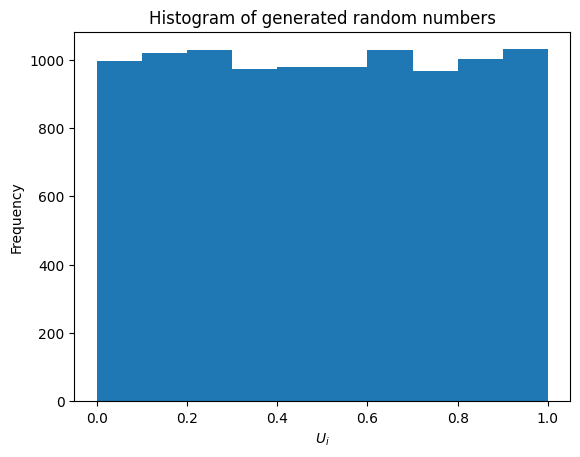

In [26]:
a = 1664525
c = 1013904223
M = 2**32
length = 10000
seed = 0

rng = LGC(a,c,M,length,seed)
data = rng.genList()

plt.hist(data)
plt.xlabel(r"$U_i$")
plt.ylabel("Frequency")
plt.title("Histogram of generated random numbers")
plt.show()

### 2)

In [27]:
#Chi^2-test:
def chi2(samples,bucket_amount):

    observed = [0]*bucket_amount

    for x in samples:
        if x*bucket_amount == bucket_amount:
            bucket = bucket_amount - 1
        
        else:
            bucket = math.floor(x * bucket_amount)
        
        observed[bucket] += 1

    expected = [len(samples) / bucket_amount] * bucket_amount

    T = 0
    for i in range(0,bucket_amount):
        T += ( ( observed[i] - expected[i] )**2 ) / expected[i]

    return 1-stats.chi2.cdf(T, df=bucket_amount - 1)

#Kolmogorov-Smirnov (KS-test):
def KS(samples):
    samples_sorted = sorted(samples)

    Dn = 0

    for i, x in enumerate(samples_sorted):
        F_emp = (i + 1) / len(samples)
        F_theory = x
        
        Dn_new = abs(F_emp - F_theory)

        if Dn_new > Dn:
            Dn = Dn_new

    Dn_adj = (np.sqrt(len(samples)) + 0.12 + 0.11/np.sqrt(len(samples))) * Dn

    return Dn_adj

#Wald-Wolfowitz (WW-test):
def WW_run(samples):
    median = np.median(samples)

    sample_labels = ['above' if x > median else 'below' for x in samples]

    n1 = sample_labels.count("above")
    n2 = sample_labels.count("below")

    runs = 1
    for i in range(1,len(samples)):
        if sample_labels[i] != sample_labels[i-1]:
            runs += 1

    expected_number,variance = [ ((2*n1*n2)/(n1+n2))+1,(2*n1*n2*(2*n1*n2-n1-n2))/(((n1+n2)**2)*(n1+n2-1)) ]

    #z = (runs - expected) / np.sqrt(variance)

    return runs,expected_number,variance


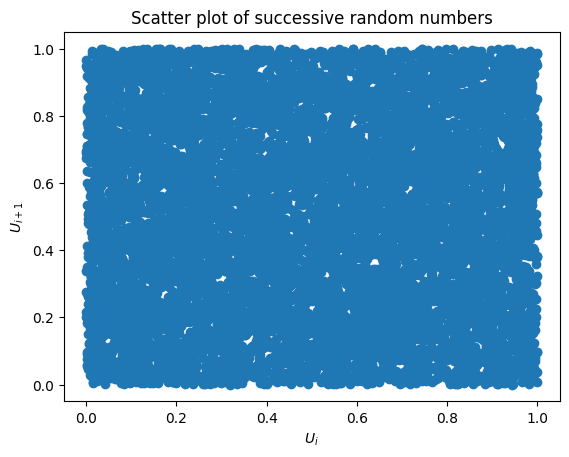

Chi2-test: 0.8022366187126961
KS-test: 0.6403581022604472
WW_run-test: (4976, 5001.0, 2499.7499749975)


In [28]:
buckets = 10

#Scatter plot
x = data[:-1]   # U_i
y = data[1:]    # U_i+1

plt.scatter(x,y)
plt.xlabel(r"$U_i$")
plt.ylabel(r"$U_{i+1}$")
plt.title("Scatter plot of successive random numbers")
plt.show()

print("Chi2-test:",chi2(data,buckets))

print("KS-test:",KS(data))

print("WW_run-test:",WW_run(data))

### 3)

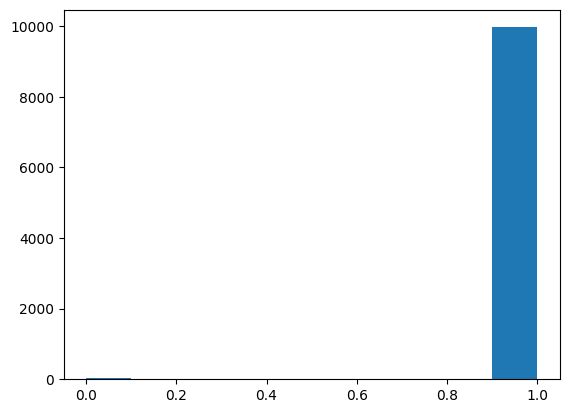

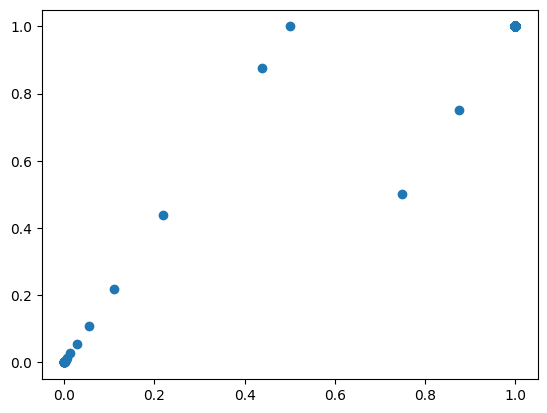

Chi2-test: 0.0
KS-test: 99.80071231682118
WW_run-test: (1, 1.0, 0.0)


In [29]:
a_bad = 2
c_bad = 7
M_bad = 2**32
length = 10000
seed = 0

rng_bad = LGC(a_bad,c_bad,M_bad,length,seed)
data_bad = rng_bad.genList()

plt.hist(data_bad)
plt.show()


#Scatter plot
x = data_bad[:-1]   # U_i
y = data_bad[1:]    # U_i+1

plt.scatter(x,y)
plt.show()

print("Chi2-test:",chi2(data_bad,buckets))

print("KS-test:",KS(data_bad))

print("WW_run-test:",WW_run(data_bad))

## Part 2

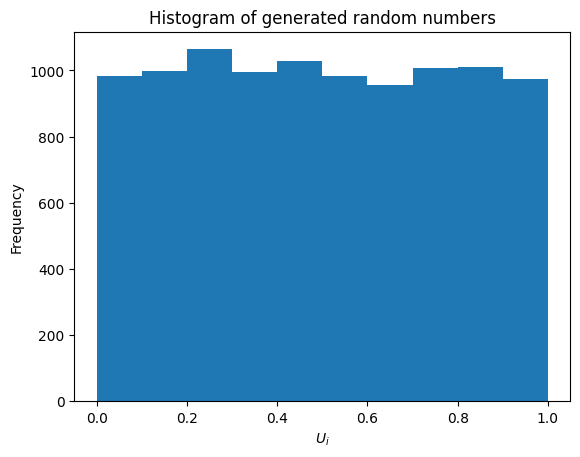

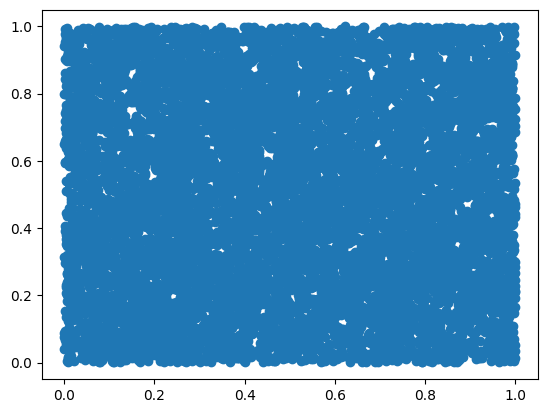

Chi2-test: 0.47594774351575597
KS-test: 0.6403581022604472
WW_run-test: (4976, 5001.0, 2499.7499749975)


In [ ]:
data_system = [random.random() for _ in range(length)]

#Scatter plot
x = data_system[:-1]   # U_i
y = data_system[1:]    # U_i+1

plt.hist(data_system)
plt.xlabel(r"$U_i$")
plt.ylabel("Frequency")
plt.title("Histogram of generated random numbers")
plt.show()

plt.scatter(x,y)
plt.xlabel(r"$U_i$")
plt.ylabel(r"$U_{i+1}$")
plt.title("Scatter plot of successive random numbers")
plt.show()

print("Chi2-test:",chi2(data_system,buckets))

print("KS-test:",KS(data))

print("WW_run-test:",WW_run(data))

## Part 3

In [31]:
reps = 10

res1_chi2 = []
res1_KS = []
res1_WW = []

res2_chi2 = []
res2_KS = []
res2_WW = []

for rep in range(reps):
    rng = LGC(a,c,M,length,seed)
    data1 = rng.genList()
    
    data2 = [random.random() for _ in range(length)]

    res1_chi2.append(chi2(data1, buckets))
    res1_KS.append(KS(data1))
    res1_WW.append(WW_run(data1))

    res2_chi2.append(chi2(data2, buckets))
    res2_KS.append(KS(data2))
    res2_WW.append(WW_run(data2))

print("Average Chi2 statistic of data1:", np.mean(res1_chi2))
print("Average KS statistic of data1:", np.mean(res1_KS))
print("Average WW statistic of data1:", np.mean(res1_WW))

print("Average Chi2 statistic of data2:", np.mean(res2_chi2))
print("Average KS statistic of data2:", np.mean(res2_KS))
print("Average WW statistic of data2:", np.mean(res2_WW))

Average Chi2 statistic of data1: 0.8022366187126961
Average KS statistic of data1: 0.6403581022604472
Average WW statistic of data1: 4158.9166583324995
Average Chi2 statistic of data2: 0.6893586149990198
Average KS statistic of data2: 0.8857108560041933
Average WW statistic of data2: 4167.949991665833
